Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

Load dataset ([IMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset))

In [2]:
df = pd.read_csv("movie_metadata.csv")

df.head()



,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [3]:
print("Dataset Shape:", df.shape)
print("\nAttributes in dataset:", df.columns.tolist())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics for numeric columns:")
df.describe()

Dataset Shape: (5043, 28)

Attributes in dataset: ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

Missing values per column:
color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users        

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


Handle Missing Values on the Dataset

In [4]:
df['budget'] = df['budget'].replace(0, np.nan)
df['gross'] = df['gross'].replace(0, np.nan)

numeric_cols = ['budget','gross','imdb_score','cast_total_facebook_likes','duration','title_year']
for col in numeric_cols:
  df[col] = df[col].fillna(df[col].median())

There are different currencies throughout the dataset, let's stick to USD to ensure accurate calculations

In [5]:
df = df[df['country'] == 'USA'].copy()

Let's define a ROI (return on investment) feature on the dataset

In [ ]:
df['roi'] = df['gross'] / df['budget']

# handle infinite / nan just in case
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan)
df['roi'] = df['roi'].fillna(df['roi'].median())


Define the features to be used from the dataset

In [14]:
# log transform for handling outliers, better scaling & better clustering
df['budget_log'] = np.log1p(df['budget'])
df['gross_log'] = np.log1p(df['gross'])
df['roi_log'] = np.log1p(df['roi'])

features_to_use = [
    'budget_log',
    'gross_log',
    'roi_log',
    'imdb_score',
    'cast_total_facebook_likes', 
    'duration',
    'title_year',
    'genres'
]

df_selected = df[features_to_use]

Data Exploration


Summary statistics:
        budget_log    gross_log      roi_log   imdb_score  \
count  3807.000000  3807.000000  3807.000000  3807.000000   
mean     16.518377    16.782443     1.126357     6.367428   
std       1.670946     1.963198     1.066202     1.125015   
min       5.389072     6.556778     0.000086     1.600000   
25%      15.894952    16.387861     0.477770     5.700000   
50%      16.811243    17.054875     0.822880     6.500000   
75%      17.622173    17.937392     1.377462     7.100000   
max      19.519293    20.449494     9.810702     9.300000   

       cast_total_facebook_likes     duration   title_year  
count                3807.000000  3807.000000  3807.000000  
mean                10891.124770   106.429735  2002.135802  
std                 19959.446892    23.707409    12.727765  
min                     0.000000     7.000000  1916.000000  
25%                  1808.500000    93.000000  1999.000000  
50%                  3681.000000   103.000000  2005.000000  
75

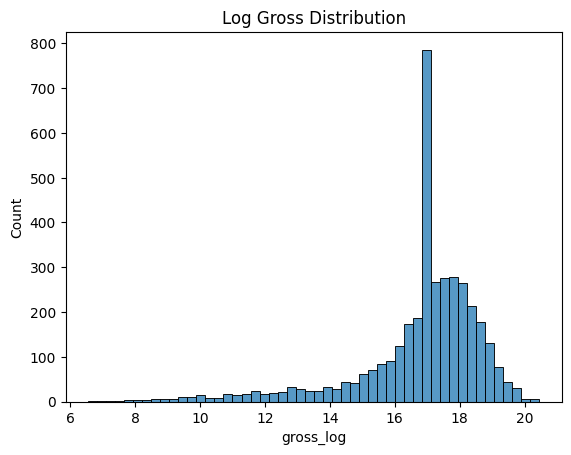

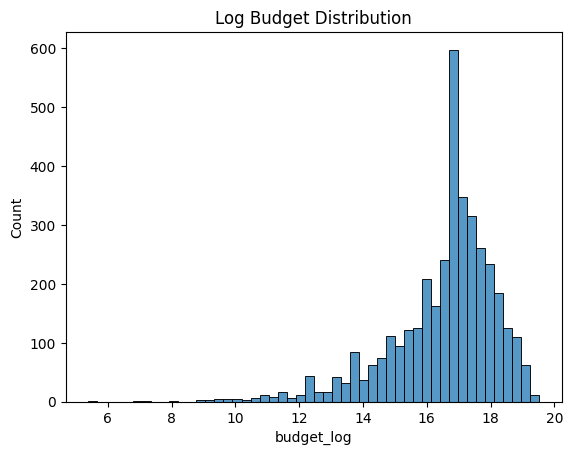

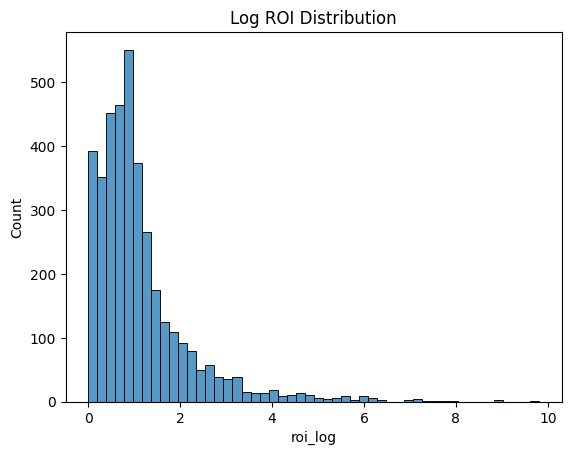

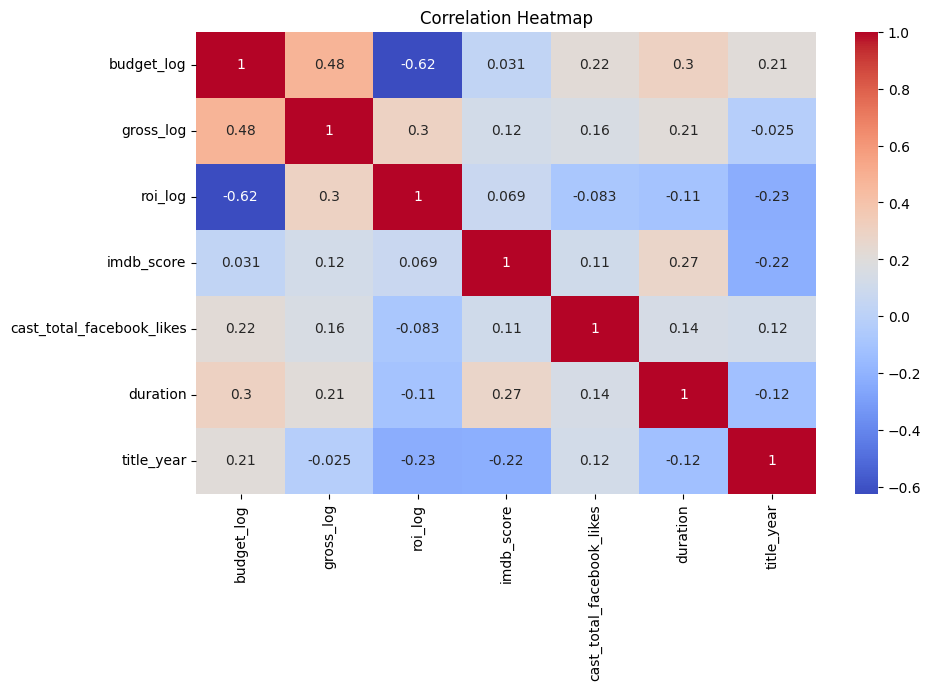

In [17]:
print("\nSummary statistics:")
print(df_selected.describe())

sns.histplot(df_selected['gross_log'], bins=50)
plt.title("Log Gross Distribution")
plt.show()

sns.histplot(df_selected['budget_log'], bins=50)
plt.title("Log Budget Distribution")
plt.show()

sns.histplot(df_selected['roi_log'], bins=50)
plt.title("Log ROI Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_selected[['budget_log','gross_log','roi_log','imdb_score','cast_total_facebook_likes','duration','title_year']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Encode the categorical genre feature

In [18]:
# genres are seperated by | on the dataset
genre_dummies = df_selected['genres'].str.get_dummies(sep='|')

# Drop the original 'genres' column and concatenate the new dummy columns
df_encoded = pd.concat([df_selected.drop('genres', axis=1), genre_dummies], axis=1)

print(f"\nNumber of unique genres extracted: {genre_dummies.shape[1]}")


Number of unique genres extracted: 26
